In [1]:
from PIL import (
    Image,
    ImageFilter,
    ImageOps,
    ImageStat,
    ImageColor,
    ImageChops,
    ImageDraw,
    ImageFont,
    ImageFilter,
)


from PIL import ImageStat as stat
from typing import Callable
from typing import Tuple, List


import matplotlib.pyplot as plt
import numpy as np
import math

# Zadanie 1

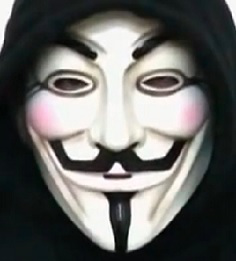

In [9]:
image = Image.open("mmaska3.jpg").convert("RGB")
obraz = Image.open("obraz.png")
wd1 = Image.open("WD1.jpg")  
image

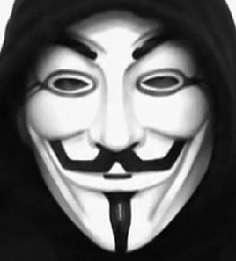

In [10]:
maska = image.convert("L")
maska

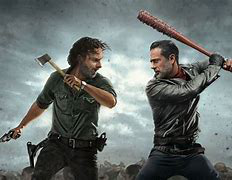

In [11]:
wd1

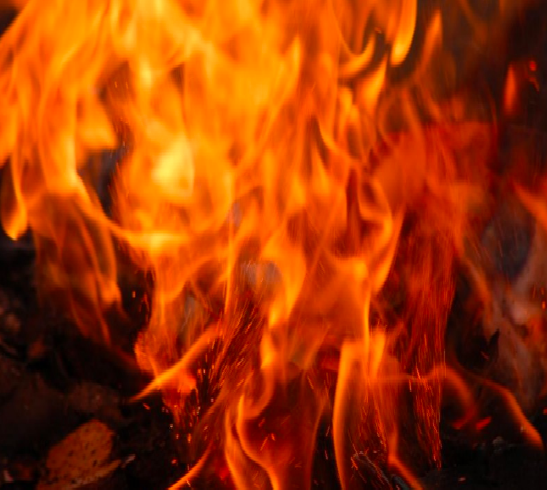

In [13]:
obraz

In [14]:
maska = maska.resize(obraz.size, Image.ANTIALIAS)
wd1 = wd1.resize(obraz.size, Image.ANTIALIAS)

C:\Users\hromn\AppData\Local\Temp\ipykernel_24556\4237764906.py:1: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  maska = maska.resize(obraz.size, Image.ANTIALIAS)
C:\Users\hromn\AppData\Local\Temp\ipykernel_24556\4237764906.py:2: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  wd1 = wd1.resize(obraz.size, Image.ANTIALIAS)


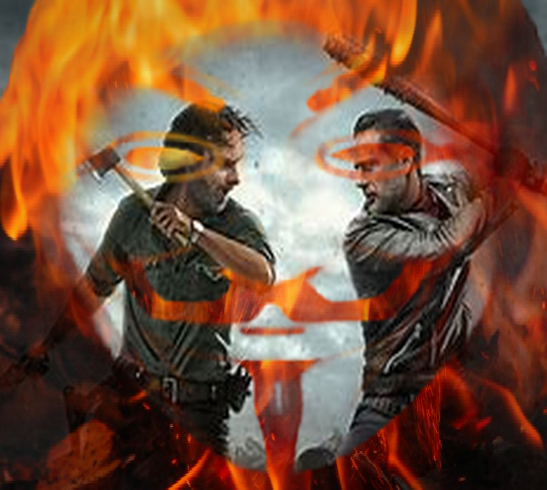

In [16]:
obraz.paste(wd1, (0, 0), maska)
obraz

In [18]:
obraz.save("zadanie1.jpg")

# Zadanie 2

In [21]:
def hex_to_rgb(value):
    value = value.lstrip("#")
    lv = len(value)
    return tuple(int(value[i : i + lv // 3], 16) for i in range(0, lv, lv // 3))


print(hex_to_rgb("#ffffff"))

def wypisz_kolory():
    for n, hex in ImageColor.colormap.items():
        if len(hex) == 3:
            hex = rgb_to_hex(hex[0], hex[1], hex[2])
        print(n, hex, hex_to_rgb(hex))


print(len(ImageColor.colormap))

wypisz_kolory()

(255, 255, 255)
148
aliceblue #f0f8ff (240, 248, 255)
antiquewhite #faebd7 (250, 235, 215)
aqua #00ffff (0, 255, 255)
aquamarine #7fffd4 (127, 255, 212)
azure #f0ffff (240, 255, 255)
beige #f5f5dc (245, 245, 220)
bisque #ffe4c4 (255, 228, 196)
black #000000 (0, 0, 0)
blanchedalmond #ffebcd (255, 235, 205)
blue #0000ff (0, 0, 255)
blueviolet #8a2be2 (138, 43, 226)
brown #a52a2a (165, 42, 42)
burlywood #deb887 (222, 184, 135)
cadetblue #5f9ea0 (95, 158, 160)
chartreuse #7fff00 (127, 255, 0)
chocolate #d2691e (210, 105, 30)
coral #ff7f50 (255, 127, 80)
cornflowerblue #6495ed (100, 149, 237)
cornsilk #fff8dc (255, 248, 220)
crimson #dc143c (220, 20, 60)
cyan #00ffff (0, 255, 255)
darkblue #00008b (0, 0, 139)
darkcyan #008b8b (0, 139, 139)
darkgoldenrod #b8860b (184, 134, 11)
darkgray #a9a9a9 (169, 169, 169)
darkgrey #a9a9a9 (169, 169, 169)
darkgreen #006400 (0, 100, 0)
darkkhaki #bdb76b (189, 183, 107)
darkmagenta #8b008b (139, 0, 139)
darkolivegreen #556b2f (85, 107, 47)
darkorange #ff8c0

# Zadanie 3

In [23]:
wd1 = Image.open("WD1.jpg")
wd1_resized = wd1.resize((500, 400), Image.LANCZOS)

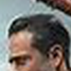

In [24]:
center_x, center_y = 350, 110
side = 71
left = center_x - side // 2
top = center_y - side // 2
right = left + side
bottom = top + side

# 4. Wytnij wycinek
square_crop = wd1_resized.crop((left, top, right, bottom))
square_crop

In [25]:
# 5. Oblicz medianę wycinka
# Konwersja obrazu do numpy array (konieczne do obliczeń numerycznych)
square_array = np.array(square_crop)
median_value = np.median(square_array)

# Wynik mediany
print("Mediana wycinka:", median_value)

Mediana wycinka: 106.0


In [26]:
def statystyki(im):
    s = stat.Stat(im)
    print(f"extrema: {s.extrema}")  # max i min
    print(f"count: {s.count}")  # ilość pixeli
    print(f"mean: {[round(value, 2) for value in s.mean]}")  # średnia
    print(f"median: {s.median}")  # mediana
    print(
        f"stddev: {[round(value, 2) for value in s.stddev]}"
    )  # odchylenie standardowe zaokrągłone do dwóch miejsc po przecinku


statystyki(square_crop)

extrema: [(0, 239), (0, 240), (0, 242)]
count: [5041, 5041, 5041]
mean: [115.12, 108.73, 103.54]
median: [126, 104, 93]
stddev: [59.4, 62.1, 63.66]


# Zadanie 4

In [32]:
kwiaty = Image.open("kwiaty.png")
kwiaty.size

(770, 772)

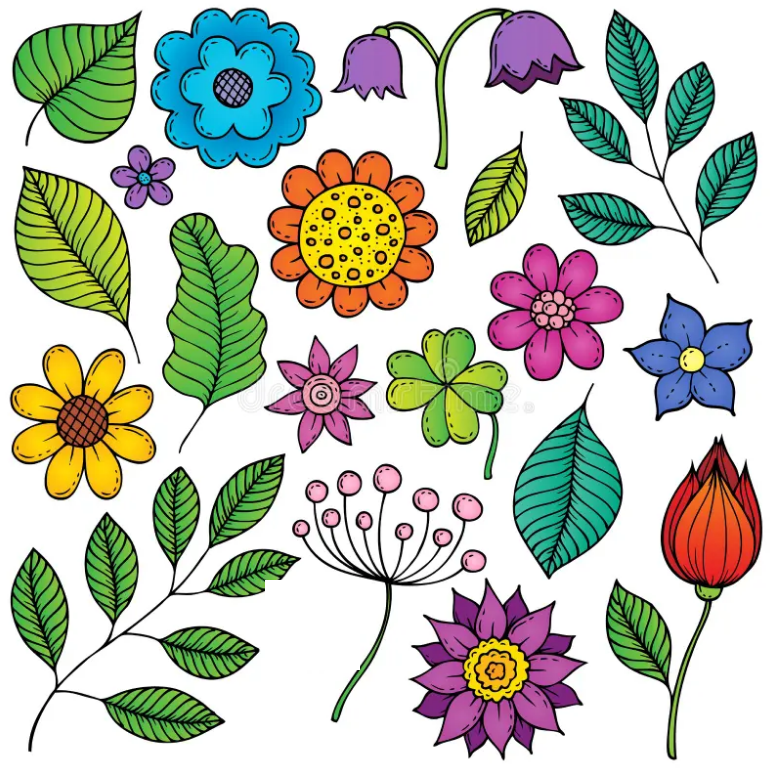

In [45]:
def wytnij_i_zmien(
    img: Image.Image,
    box: tuple[int, int, int, int],
    zmiana=None,
    cel: tuple[int, int] | None = None,
    maska: Image.Image | None = None,
) -> Image.Image:
    if cel is None:
        cel = (box[0], box[1]) 

    out_img = img.copy()
    wycinek = img.crop(box)

    new_wycinek = wycinek
    if zmiana is not None:
        new_wycinek = zmiana(new_wycinek)

    out_img.paste(new_wycinek, cel, maska)
    return out_img

def na_bialy(wycinek: Image.Image) -> Image.Image:
    return Image.new("RGB", wycinek.size, (255, 255, 255))

kwiatek_box = (265, 580, 360, 670)  

kwiaty_result = wytnij_i_zmien(kwiaty, kwiatek_box, zmiana=na_bialy)

output_path = "kwiaty_wynik.png"
kwiaty_result.save(output_path)

kwiaty_result


# Zadanie 5

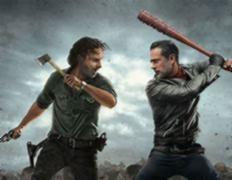

In [47]:
wd_filtr1 = Image.open("wd_filtr1.png")
wd_filtr1

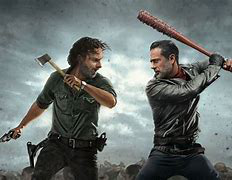

In [48]:
WD1 = Image.open("WD1.jpg")
WD1

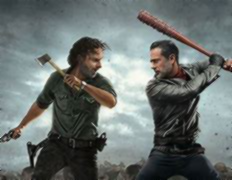

In [51]:
im_filtered = WD1.filter(ImageFilter.SMOOTH)
im_filtered

In [ ]:
difference = ImageChops.difference(im_filtered, image2)

In [ ]:
d = im.filter(ImageFilter.Kernel(size = (3, 3), scale = 13, offset = 0, kernel=(1, 1, 1, 1, 5, 1, 1, 1, 1)))

# Zadanie 6

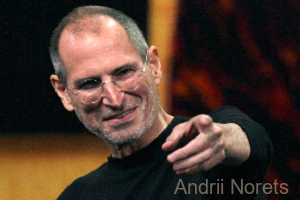

In [61]:
image = Image.open("steve.png" ).convert("RGBA")

pixel_color = image.getpixel((240, 140))

txt_overlay = Image.new("RGBA", image.size, (255, 255, 255, 0))
draw = ImageDraw.Draw(txt_overlay)

text = "Andrii Norets" 
font_size = 20
font = ImageFont.load_default() 

font = ImageFont.truetype("arial.ttf", font_size)

text_bbox = draw.textbbox((0, 0), text, font=font) 
text_width = text_bbox[2] - text_bbox[0]
text_height = text_bbox[3] - text_bbox[1]

padding = 10
x = image.width - text_width - padding
y = image.height - text_height - padding

text_color = (*pixel_color[:3], 128)
draw.text((x, y), text, fill=text_color, font=font)

combined = Image.alpha_composite(image, txt_overlay)

combined.save("steve_Andrii_Norets.png")
combined

# Zadanie 7

# Zadanie 8

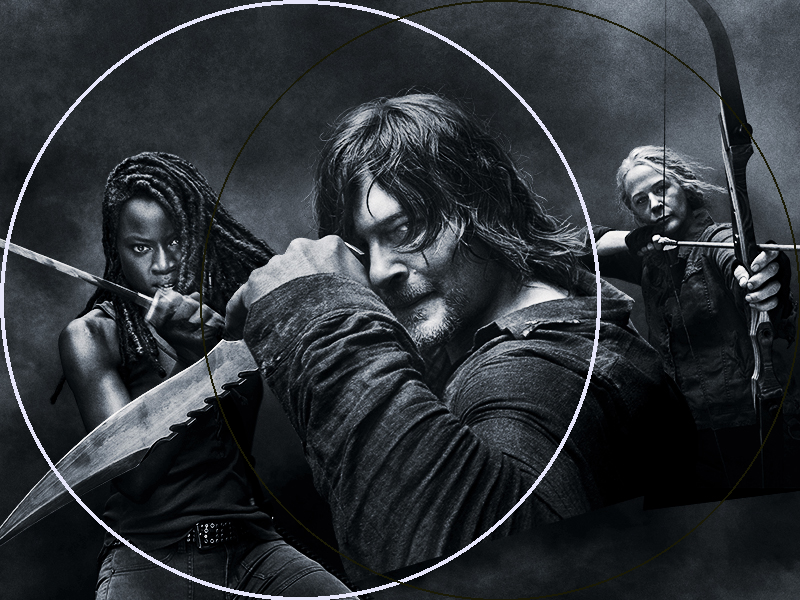

In [63]:
from PIL import Image, ImageDraw
 
image = Image.open("WD2.jpg")
draw = ImageDraw.Draw(image)

width, height = image.size

circle_thickness_left = 4  
circle_thickness_right = 2  

circle_left_bounds = (0, 0, height, height)  
draw.ellipse(circle_left_bounds, outline="lavender", width=circle_thickness_left)

negative_color = (255 - 230, 255 - 230, 255 - 250)  
circle_right_bounds = (width - height, 0, width, height)  
draw.ellipse(circle_right_bounds, outline=negative_color, width=circle_thickness_right)

image.save("WD2_result.jpg")
image

# Zadanie 9

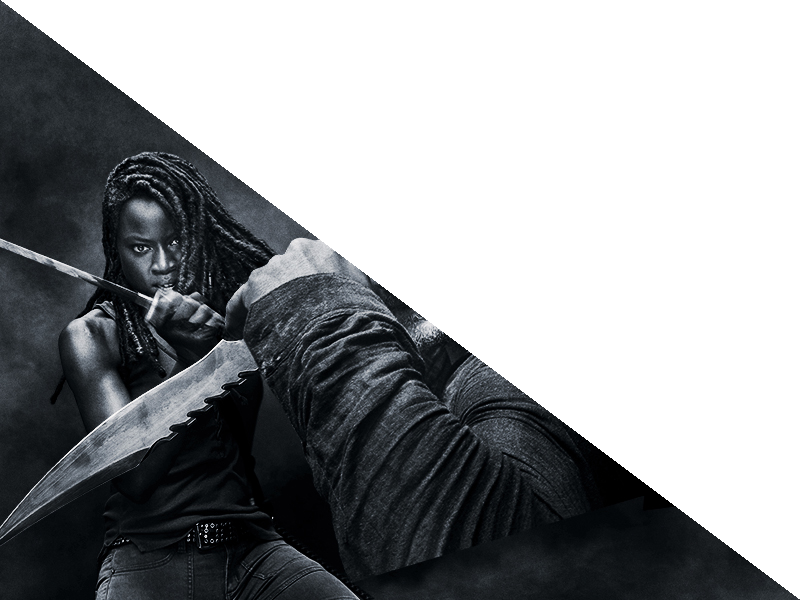

In [69]:
image_path = "WD2.jpg"

image = Image.open(image_path).convert("RGBA")
w, h = image.size

alpha_layer = Image.new("L", (w, h), 0)
draw = ImageDraw.Draw(alpha_layer)
draw.polygon([(0, 0), (w, h), (0, h)], fill=255)

rgba_image = Image.new("RGBA", (w, h))
for y in range(h):
    for x in range(w):
        r, g, b = image.getpixel((x, y))[:3]
        alpha = alpha_layer.getpixel((x, y))
        rgba_image.putpixel((x, y), (r, g, b, alpha))

rgba_image.save("rgba.png")

rgba_image

In [72]:
image_path = "WD1.jpg" 
image = Image.open(image_path)

cmyk_image = image.convert("CMYK")

y_channel = np.array(cmyk_image.getchannel("M"))

mean_y = round(np.mean(y_channel), 1)  
median_y = round(np.median(y_channel), 1) 
count_130 = np.sum(y_channel == 130 )

print(f"{mean_y} / {median_y} / {count_130}")

140.5 / 137.0 / 228


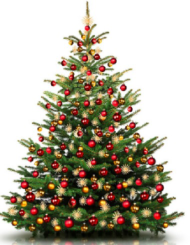

In [77]:
image = Image.open("choinka2.jpg")
resized_image = image.resize((image.width // 2, image.height // 2), resample=Image.HAMMING)  

resized_image

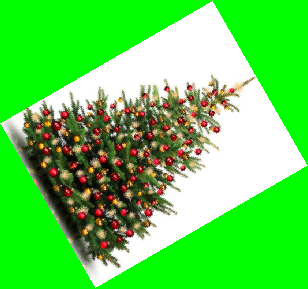

In [82]:
rot60 = resized_image.rotate(-60, expand=1, fillcolor=(0, 255, 0))
rot60

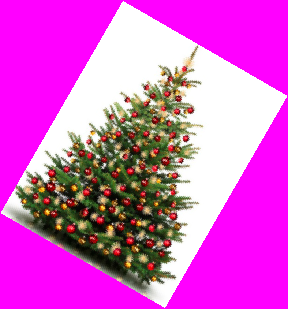

In [86]:
image = Image.open("choinka2.jpg")
resized_image = image.resize((image.width // 2, image.height // 2), resample=Image.HAMMING)

rotated_image = resized_image.rotate(-30, expand=True, fillcolor=(255, 0, 255))

rotated_image 


In [90]:
image = Image.open("WD3.jpg").convert("CMYK")

In [ ]:
image

In [91]:
from PIL import Image

image = Image.open("WD3.jpg")

cmyk_image = image.convert("CMYK")

# Pobranie wartości piksela (100, 200)
pixel_value = cmyk_image.getpixel((100, 200))

# Wyświetlenie wartości piksela
print("Wartość piksela (100, 200) w trybie CMYK:", pixel_value)

# Zapis przekonwertowanego obrazu (opcjonalnie)
# cmyk_image.save("WD3_CMYK.jpg")


Wartość piksela (100, 200) w trybie CMYK: (115, 128, 172, 0)


# gaavnoo

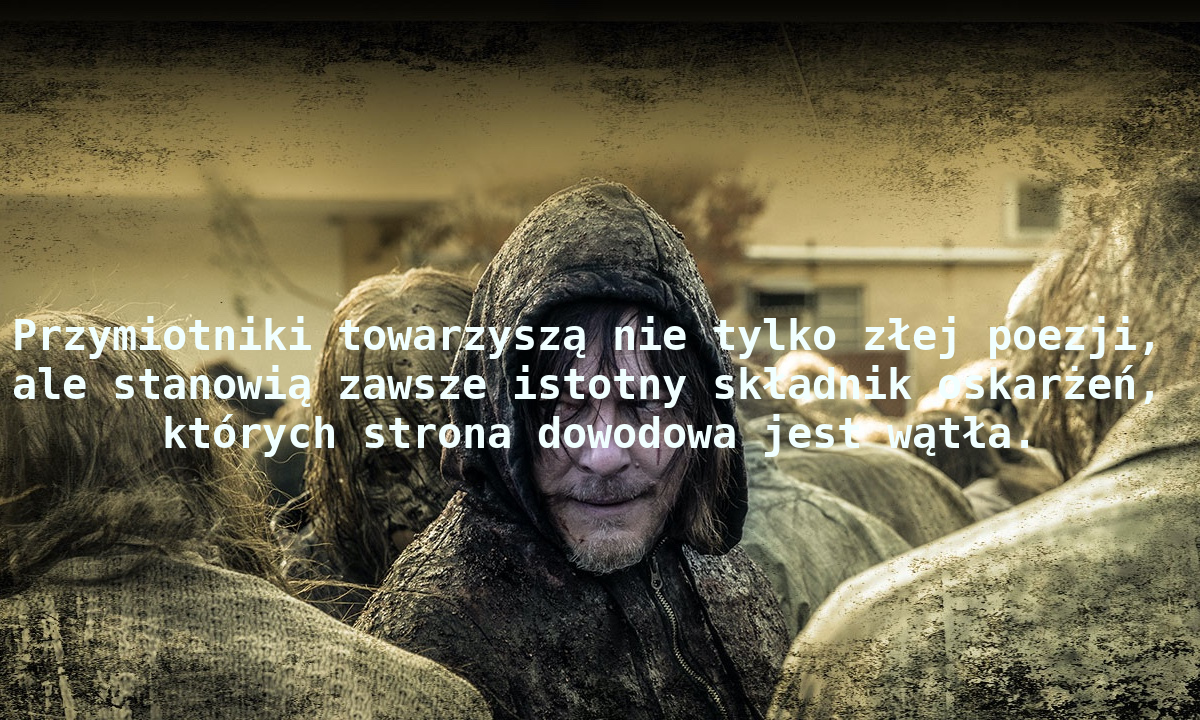

In [95]:
font_path = "DejaVuSansMono-Bold.ttf"

text = """
Przymiotniki towarzyszą nie tylko złej poezji, 
ale stanowią zawsze istotny składnik oskarżeń, 
których strona dowodowa jest wątła.
"""

text_color = "azure"

image = Image.open("WD3.jpg")
draw = ImageDraw.Draw(image)

image_width, image_height = image.size

max_font_size = 1
font = None

for font_size in range(1, 200):  
    next_font = ImageFont.truetype(font_path, font_size)
    text_bbox = draw.multiline_textbbox((0, 0), text, font=next_font, spacing=5, align="center")
    text_width, text_height = text_bbox[2] - text_bbox[0], text_bbox[3] - text_bbox[1]
    if text_height <= image_height and text_width <= image_width:
        font = next_font
        max_font_size = font_size
    else:
        break

text_bbox = draw.multiline_textbbox((0, 0), text, font=font, spacing=10, align="center")
text_width, text_height = text_bbox[2] - text_bbox[0], text_bbox[3] - text_bbox[1]
text_x = (image_width - text_width) // 2
text_y = (image_height - text_height) // 2

draw.multiline_text((text_x, text_y), text, font=font, fill=text_color, spacing=10, align="center")

image.save("zad7_result.jpg")

image

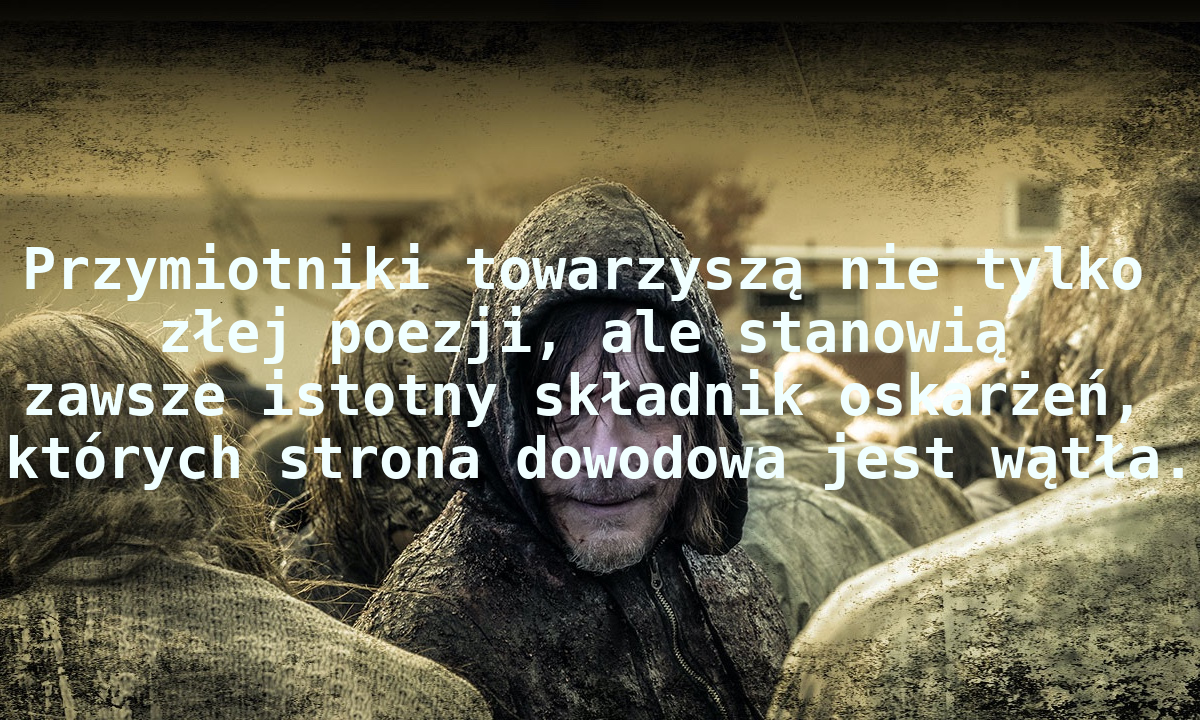

In [97]:
from PIL import Image, ImageDraw, ImageFont

font_path = "DejaVuSansMono-Bold.ttf"

text = """Przymiotniki towarzyszą nie tylko 
złej poezji, ale stanowią 
zawsze istotny składnik oskarżeń, 
których strona dowodowa jest wątła."""

text_color = "azure"

image = Image.open("WD3.jpg")
draw = ImageDraw.Draw(image)


image_width, image_height = image.size

max_font_size = 1
font = None

for font_size in range(1, 200):  
    next_font = ImageFont.truetype(font_path, font_size)
    text_bbox = draw.multiline_textbbox((0, 0), text, font=next_font, spacing=5, align="center")
    text_width, text_height = text_bbox[2] - text_bbox[0], text_bbox[3] - text_bbox[1]
    
    if text_height <= image_height and text_width <= image_width:
        font = next_font
        max_font_size = font_size
    else:
        break

text_bbox = draw.multiline_textbbox((0, 0), text, font=font, spacing=10, align="center")
text_width, text_height = text_bbox[2] - text_bbox[0], text_bbox[3] - text_bbox[1]
text_x = (image_width - text_width) // 2
text_y = (image_height - text_height) // 2

draw.multiline_text((text_x, text_y), text, font=font, fill=text_color, spacing=10, align="center")

image.save("zad7_result.jpg")
image


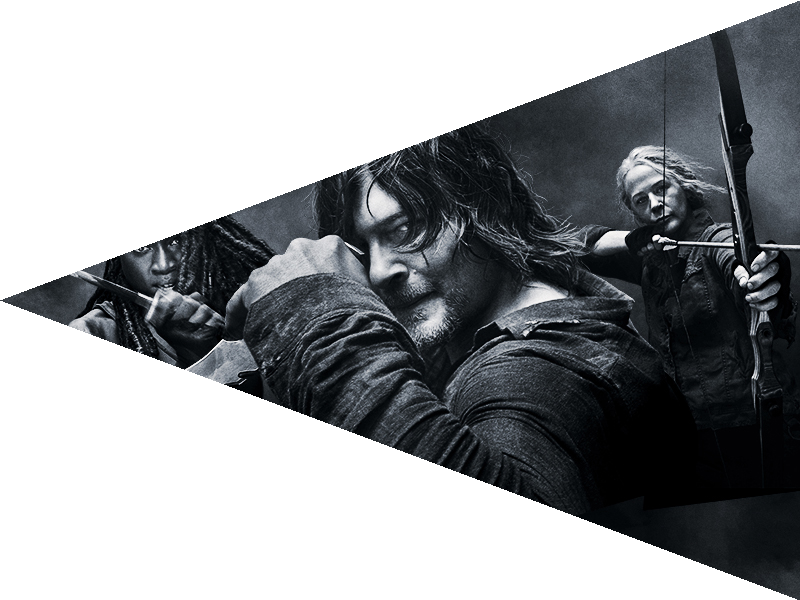

In [99]:
from PIL import Image, ImageDraw

input_image = Image.open("WD2.jpg")
w, h = input_image.size

alpha = Image.new("L", (w, h), 0)
draw = ImageDraw.Draw(alpha)

draw.polygon([(0, h // 2), (w, 0), (w, h), ( w, h)], fill=255)

rgba_image = input_image.convert("RGBA")
rgba_image.putalpha(alpha)

rgba_image.save("rgba.png")
rgba_image

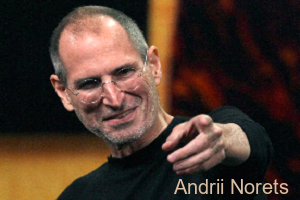

In [100]:
image = Image.open("steve.png" ).convert("RGBA")

pixel_color = image.getpixel((240, 140))

txt_overlay = Image.new("RGBA", image.size, (255, 255, 255, 0))
draw = ImageDraw.Draw(txt_overlay)

text = "Andrii Norets" 
font_size = 20
font = ImageFont.load_default() 

font = ImageFont.truetype("arial.ttf", font_size)

text_bbox = draw.textbbox((0, 0), text, font=font) 
text_width = text_bbox[2] - text_bbox[0]
text_height = text_bbox[3] - text_bbox[1]

padding = 10
x = image.width - text_width - padding
y = image.height - text_height - padding

text_color = (*pixel_color[:3], 384)
draw.text((x, y), text, fill=text_color, font=font)

combined = Image.alpha_composite(image, txt_overlay)

combined.save("steve_Andrii_Norets.png")
combined